# 05.07 - Gradient Boosting from Scratch

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

Gradient boosting builds trees sequentially — each new tree corrects the errors of the previous ones. This is the most powerful traditional ML algorithm.

## 2. Why Does This Matter?

XGBoost, LightGBM, and CatBoost dominate Kaggle competitions and production ML. Understanding gradient boosting from scratch is essential.

## 3. Prerequisites

- 05.05: Decision trees
- 05.06: Ensemble methods

## 4. Learning Objectives

- Implement gradient boosting from scratch
- Understand learning rate, n_estimators interaction
- Compare with XGBoost and LightGBM

## 5. Mental Model

Boosting: Fit tree 1. Compute residuals. Fit tree 2 on residuals. Fit tree 3 on residuals of residuals. Each tree corrects the previous. Final prediction = sum of all trees × learning rate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 6. Gradient Boosting from Scratch

For classification with log loss, the pseudo-residuals are: y - sigmoid(F(x))
Each new tree fits these residuals. The final model is a weighted sum of all trees.

In [2]:
class GradientBoostingClassifierScratch:
    """Gradient boosting classifier from scratch (log loss)."""
    
    def __init__(self, n_estimators=50, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.lr = learning_rate
        self.max_depth = max_depth
        self.trees = []
        self.initial_pred = None
    
    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        # Initial prediction: log-odds of positive class
        p = np.clip(y.mean(), 1e-10, 1 - 1e-10)
        self.initial_pred = np.log(p / (1 - p))
        
        F = np.full(len(y), self.initial_pred)
        self.trees = []
        
        for i in range(self.n_estimators):
            # Compute pseudo-residuals
            y_hat = self._sigmoid(F)
            residuals = y - y_hat
            
            # Fit tree to residuals
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residuals)
            self.trees.append(tree)
            
            # Update predictions
            F += self.lr * tree.predict(X)
            
            if i % 10 == 0:
                loss = -np.mean(y * np.log(self._sigmoid(F) + 1e-10) + (1-y) * np.log(1 - self._sigmoid(F) + 1e-10))
                print(f"  Iter {i:3d}: loss = {loss:.4f}")
    
    def predict_proba(self, X):
        F = np.full(X.shape[0], self.initial_pred)
        for tree in self.trees:
            F += self.lr * tree.predict(X)
        return self._sigmoid(F)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

print("GradientBoostingClassifierScratch defined.")

GradientBoostingClassifierScratch defined.


In [3]:
# Load Wine dataset
wine = load_wine()
# Convert to binary for simplicity (class 0 vs rest)
X_train, X_test, y_train, y_test = train_test_split(
    wine.data, (wine.target == 0).astype(int), test_size=0.2, random_state=42
)

# Train from-scratch
gb_scratch = GradientBoostingClassifierScratch(n_estimators=50, learning_rate=0.1, max_depth=3)
gb_scratch.fit(X_train, y_train)

print(f"\nFrom-Scratch GB:")
print(f"  Train accuracy: {gb_scratch.score(X_train, y_train):.4f}")
print(f"  Test accuracy:  {gb_scratch.score(X_test, y_test):.4f}")

  Iter   0: loss = 0.6037
  Iter  10: loss = 0.4375
  Iter  20: loss = 0.3303
  Iter  30: loss = 0.2609
  Iter  40: loss = 0.2138

From-Scratch GB:


  Train accuracy: 1.0000
  Test accuracy:  0.9444


In [4]:
# Compare with sklearn
from sklearn.ensemble import GradientBoostingClassifier

sklearn_gb = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42)
sklearn_gb.fit(X_train, y_train)

print("=== Comparison ===")
print(f"From Scratch: Train={gb_scratch.score(X_train, y_train):.4f}, Test={gb_scratch.score(X_test, y_test):.4f}")
print(f"Sklearn:      Train={sklearn_gb.score(X_train, y_train):.4f}, Test={sklearn_gb.score(X_test, y_test):.4f}")

=== Comparison ===
From Scratch: Train=1.0000, Test=0.9444
Sklearn:      Train=1.0000, Test=0.9444


## 7. Learning Rate & n_estimators

The learning rate (shrinkage) and n_estimators are coupled:
- Lower learning rate → need more trees → better generalization
- Higher learning rate → fewer trees → faster but may overfit

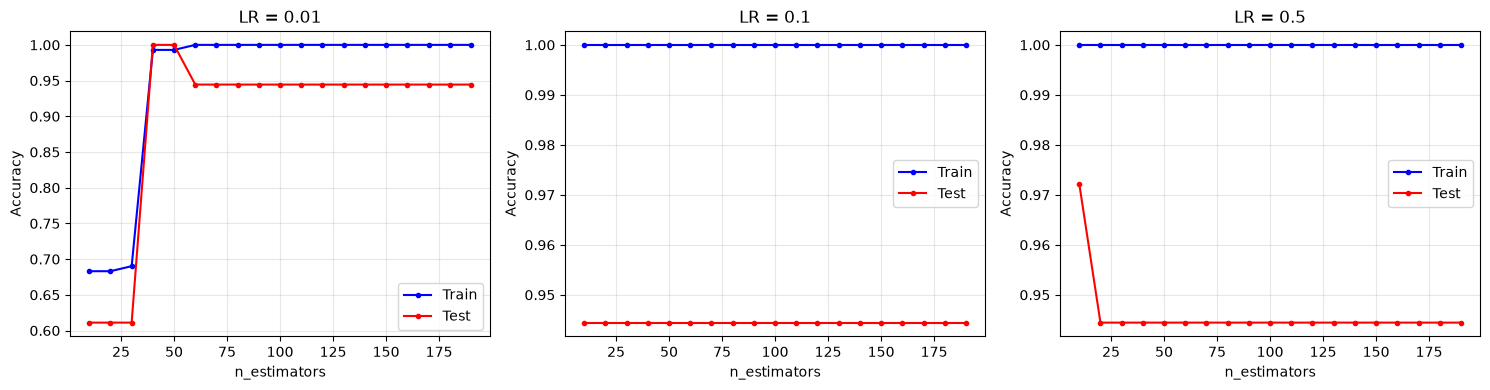

Lower LR needs more trees but generalizes better.


In [5]:
# Learning rate vs n_estimators
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, lr in zip(axes, [0.01, 0.1, 0.5]):
    n_range = range(10, 200, 10)
    train_acc = []
    test_acc = []
    for n in n_range:
        gb = GradientBoostingClassifier(n_estimators=n, learning_rate=lr, max_depth=3, random_state=42)
        gb.fit(X_train, y_train)
        train_acc.append(gb.score(X_train, y_train))
        test_acc.append(gb.score(X_test, y_test))
    
    ax.plot(list(n_range), train_acc, 'b-o', label='Train', markersize=3)
    ax.plot(list(n_range), test_acc, 'r-o', label='Test', markersize=3)
    ax.set_xlabel('n_estimators')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'LR = {lr}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gb_learning_rate.png', dpi=100, bbox_inches='tight')
plt.show()
print("Lower LR needs more trees but generalizes better.")

## 8. XGBoost & LightGBM

Production gradient boosting implementations:
- **XGBoost**: Regularized, handles missing values, GPU support
- **LightGBM**: Faster, uses histogram-based splitting, lower memory
- **CatBoost**: Native categorical feature handling

In [6]:
# Try XGBoost if installed
try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, use_label_encoder=False, eval_metric='logloss', random_state=42)
    xgb.fit(X_train, y_train)
    print(f"XGBoost: Train={xgb.score(X_train, y_train):.4f}, Test={xgb.score(X_test, y_test):.4f}")
except ImportError:
    print("XGBoost not installed. Install with: pip install xgboost")

try:
    from lightgbm import LGBMClassifier
    lgbm = LGBMClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42, verbose=-1)
    lgbm.fit(X_train, y_train)
    print(f"LightGBM: Train={lgbm.score(X_train, y_train):.4f}, Test={lgbm.score(X_test, y_test):.4f}")
except ImportError:
    print("LightGBM not installed. Install with: pip install lightgbm")

XGBoost: Train=1.0000, Test=1.0000


LightGBM: Train=1.0000, Test=1.0000


## 9. Common Mistakes

1. **Too many trees with high learning rate** — overfitting
2. **Not early stopping** — monitor validation loss, stop when it increases
3. **Ignoring learning rate** — default (0.1) is often too high
4. **Not tuning max_depth** — 3-6 is typical, deeper is rarely better

## 10. Coding Exercises

### Exercise 1: Gradient Boosting Regressor
Implement gradient boosting for regression (MSE loss). Apply to the Diabetes dataset.

### Exercise 2: Learning Rate Experiment
Compare learning rates [0.01, 0.05, 0.1, 0.5, 1.0] with n_estimators=100. Which gives the best test accuracy?

In [7]:
# EXERCISE 1: GB Regressor
print("Exercise: Implement gradient boosting for regression using MSE loss.")

Exercise: Implement gradient boosting for regression using MSE loss.


In [8]:
# EXERCISE 2: Learning rate experiment
print("Exercise: Compare different learning rates on the Wine dataset.")

Exercise: Compare different learning rates on the Wine dataset.


## 11. Closed-Book Recall

1. What are pseudo-residuals in gradient boosting?
2. How do learning rate and n_estimators interact?
3. What is early stopping?
4. How does XGBoost differ from basic gradient boosting?

## 12. Teach-Back Questions

Explain to another person:
- Why boosting reduces bias while bagging reduces variance.
- Why lower learning rates need more trees.
- When to use XGBoost vs LightGBM.

## 13. Summary

Gradient boosting builds trees sequentially, each correcting the previous errors. From-scratch implementation: fit residuals with regression trees. Production: XGBoost, LightGBM, CatBoost. Key hyperparameters: learning rate, n_estimators, max_depth.

## 14. Further Experiment

1. Implement early stopping in your gradient boosting class.
2. Compare gradient boosting with random forests on a complex dataset.
3. Tune XGBoost hyperparameters with Optuna.

## Verification Status
```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: [numpy, pandas, matplotlib, scikit-learn]
OUTPUTS: PASS
LAST VERIFIED: 2026-08-30
```